# AICE 심화 모의고사 — 기후 변화 예측

## 문제 시나리오

과거 기상 정보 및 환경 데이터(`climate_data.json`, `pollution_data.csv`)를 분석 및 전처리한 후, 머신러닝과 딥러닝으로 특정 지역의 연간 평균 기온 변화를 예측하고 결과를 심화 분석하세요.


## 4-1 | 라이브러리 임포트 및 데이터 로딩

### 【 문제 】

- pandas 라이브러리를 `pd`라는 별칭으로 임포트하세요.
- `climate_data.json` 파일을 읽어 데이터프레임 변수 `df_climate`에 할당하세요.
- `pollution_data.csv` 파일을 읽어 데이터프레임 변수 `df_pollution`에 할당하세요.

In [87]:
import pandas as pd

In [88]:
df_climate = pd.read_json('C:/juehyeon/aice_test/기출문제/4.기후변화예측/climate_data.json')

In [89]:
df_pollution = pd.read_csv('C:/juehyeon/aice_test/기출문제/4.기후변화예측/pollution_data.csv')



## 4-2 | 데이터 병합 및 초기 탐색

### 【 문제 】

- `df_climate`와 `df_pollution`을 `LocationID`와 `Year`를 키(key)로 `inner` 병합하여 `df` 변수에 저장하세요.
- `df` 데이터프레임의 상위 5개 행을 출력하세요.
- `df` 데이터프레임의 컬럼별 정보(dtype, Non-null Count)를 확인하세요.


In [90]:
df = pd.merge(df_climate, df_pollution, on = ['LocationID', 'Year'], how = 'inner')

In [91]:
df.head()

,LocationID,Year,AvgTemperature_C,CO2_Concentration_ppm,SeaLevel_mm,ForestArea_percent,UrbanArea_percent,MajorEvent,PM25_ug_m3,Ozone_ppb,IndustrialEmissions_tons
0,16,2012,15.43,592,2.7,58.4,32.3,Flood,63.7,65.4,1488
1,8,2021,27.74,450,3.4,53.2,37.5,Flood,52.8,69.1,8099
2,17,2016,29.53,403,1.6,30.5,33.5,Storm,38.3,21.2,45298
3,5,2019,29.67,446,1.8,37.9,36.3,Storm,74.5,63.2,33376
4,5,2019,29.67,446,1.8,37.9,36.3,Storm,20.6,94.4,13329


In [92]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41 entries, 0 to 40
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   LocationID                41 non-null     int64  
 1   Year                      41 non-null     int64  
 2   AvgTemperature_C          41 non-null     float64
 3   CO2_Concentration_ppm     41 non-null     int64  
 4   SeaLevel_mm               40 non-null     float64
 5   ForestArea_percent        41 non-null     float64
 6   UrbanArea_percent         41 non-null     float64
 7   MajorEvent                41 non-null     object 
 8   PM25_ug_m3                41 non-null     float64
 9   Ozone_ppb                 41 non-null     float64
 10  IndustrialEmissions_tons  41 non-null     int64  
dtypes: float64(6), int64(4), object(1)
memory usage: 3.7+ KB



## 4-3 | 범주형 변수 시각화 및 결측 카테고리 제거

### 【 문제 】

- seaborn 라이브러리의 `countplot`을 사용하여 `MajorEvent` 컬럼의 분포를 시각화하세요.
- `MajorEvent` 컬럼 값이 `'Unknown'`인 행을 데이터프레임에서 삭제하고 `df`에 재할당하세요.

In [93]:
import seaborn as sns

<Axes: xlabel='MajorEvent', ylabel='count'>

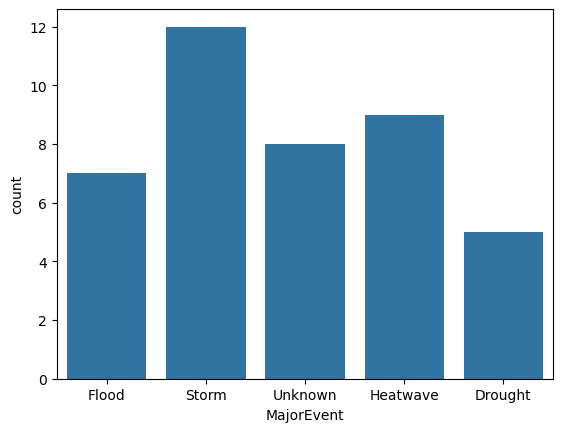

In [94]:
sns.countplot(data=df, x='MajorEvent')

In [95]:
df = df[df['MajorEvent'] != 'Unknown'].copy()


## 4-4 | IQR 기반 이상치 탐지

### 【 문제 】

- `CO2_Concentration_ppm` 컬럼의 Q1(1사분위), Q3(3사분위), IQR(=Q3-Q1)을 구하세요.
- `lower = Q1 - 1.5 * IQR`, `upper = Q3 + 1.5 * IQR`을 계산하세요.
- 이 범위(`lower` 미만 또는 `upper` 초과)를 벗어나는 행의 개수를 출력하세요.
- (생각해볼 점: 고정 임계값(500 이상)으로 판단했을 때와 IQR 기준으로 판단했을 때 결과가 같은지 다른지 비교해보세요.)sns.countplot(df['MajorEvent'])

In [96]:
Q1 = df['CO2_Concentration_ppm'].quantile(0.25)

In [97]:
Q3 = df['CO2_Concentration_ppm'].quantile(0.75)

In [98]:
IQR = Q3 - Q1 
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

In [99]:
outliers = df[(df['CO2_Concentration_ppm'] < lower) | (df['CO2_Concentration_ppm'] > upper)]

In [100]:
outliers.shape[0]

1

## 4-5 | 이상치 및 불필요 컬럼 삭제

### 【 문제 】

- 4-4에서 구한 `upper` 값을 기준으로, `CO2_Concentration_ppm`이 `upper`를 초과하는 행을 제거하세요.
- 모델링에 불필요한 `LocationID`와 `Year` 컬럼을 삭제하세요.
- 변경된 데이터프레임을 `df_cleaned`에 저장하세요. (`drop()`은 새 결과를 반환만 하므로 반드시 재할당하세요.)


In [101]:
df = df[df['CO2_Concentration_ppm'] <= upper].copy()

In [102]:
df_cleaned = df.drop(columns = ['LocationID', 'Year'])


## 4-6 | 결측치 처리 및 데이터 타입 변환

### 【 문제 】

- `df_cleaned.isna().sum()`으로 결측치 개수를 확인하세요.
- 결측치가 있는 행을 `dropna()`로 삭제하고, 결과를 `df_cleaned`에 반드시 재할당하세요.
- `SeaLevel_mm` 컬럼을 정수형(`int`)으로 변환하세요.

In [103]:
print(f'결측치 개수 :\n{df_cleaned.isna().sum()}')

결측치 개수 :
AvgTemperature_C            0
CO2_Concentration_ppm       0
SeaLevel_mm                 0
ForestArea_percent          0
UrbanArea_percent           0
MajorEvent                  0
PM25_ug_m3                  0
Ozone_ppb                   0
IndustrialEmissions_tons    0
dtype: int64


In [104]:
df_cleaned['SeaLevel_mm'] = df_cleaned['SeaLevel_mm'].astype(int)

In [105]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32 entries, 1 to 40
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   AvgTemperature_C          32 non-null     float64
 1   CO2_Concentration_ppm     32 non-null     int64  
 2   SeaLevel_mm               32 non-null     int64  
 3   ForestArea_percent        32 non-null     float64
 4   UrbanArea_percent         32 non-null     float64
 5   MajorEvent                32 non-null     object 
 6   PM25_ug_m3                32 non-null     float64
 7   Ozone_ppb                 32 non-null     float64
 8   IndustrialEmissions_tons  32 non-null     int64  
dtypes: float64(5), int64(3), object(1)
memory usage: 2.5+ KB


## 4-7 | 파생 변수 생성

### 【 문제 】

- `ForestArea_percent`를 `UrbanArea_percent`로 나눈 값을 `GreenRatio`라는 새 컬럼으로 추가하세요.
- 0으로 나누는 에러를 방지하기 위해 분모에 작은 값(`1e-6`)을 더해주세요.
- `GreenRatio` 컬럼의 기술통계(`describe()`)를 출력하세요.

In [106]:
df['GreenRatio'] = df['ForestArea_percent'] / (df['UrbanArea_percent'] + 1e-6)

In [107]:
df['GreenRatio'].describe()

count    32.000000
mean      1.921780
std       0.777650
min       0.910448
25%       1.192045
50%       1.855899
75%       2.417721
max       4.094117
Name: GreenRatio, dtype: float64


## 4-8 | 불필요 컬럼 삭제 및 원-핫 인코딩

### 【 문제 】

- `df_cleaned`에서 `UrbanArea_percent` 컬럼을 삭제하세요 (반드시 재할당).
- pandas의 `get_dummies` 함수를 활용하여 `MajorEvent` 컬럼을 원-핫 인코딩하세요.
- 변경된 결과를 `df_encoded` 변수에 저장하세요.

In [108]:
df_cleaned = df_cleaned.drop(columns = 'UrbanArea_percent')

In [115]:
df_encoded = pd.get_dummies(data = df_cleaned, columns = ['MajorEvent'])
df_encoded.head()

,AvgTemperature_C,CO2_Concentration_ppm,SeaLevel_mm,ForestArea_percent,PM25_ug_m3,Ozone_ppb,IndustrialEmissions_tons,MajorEvent_Drought,MajorEvent_Flood,MajorEvent_Heatwave,MajorEvent_Storm
1,27.74,450,3,53.2,52.8,69.1,8099,False,True,False,False
2,29.53,403,1,30.5,38.3,21.2,45298,False,False,False,True
3,29.67,446,1,37.9,74.5,63.2,33376,False,False,False,True
4,29.67,446,1,37.9,20.6,94.4,13329,False,False,False,True
5,29.67,446,1,37.9,35.4,72.3,15818,False,False,False,True


## 4-9 | 상관관계 분석 및 히트맵

### 【 문제 】

- seaborn의 `heatmap`을 사용하여 수치형 변수 간 상관관계를 시각화하세요.
- `AvgTemperature_C`와 상관관계(절댓값 기준)가 가장 강한 변수 상위 3개를 출력하세요.

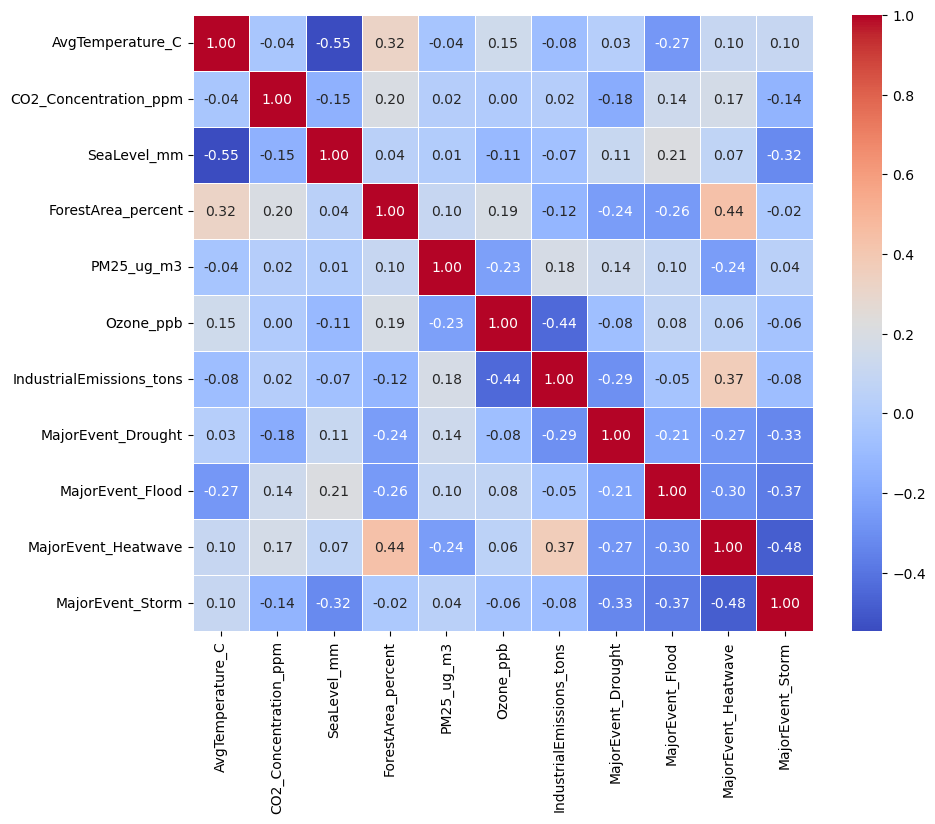

In [110]:
import matplotlib.pyplot as plt
corr_matrix = df_encoded.corr()

plt.figure(figsize = (10, 8))
sns.heatmap(
    corr_matrix,
    annot = True,
    fmt = ".2f",
    linewidths = 0.5,
    cbar = True,
    cmap = "coolwarm"
)
plt.show()

In [111]:
corr_with_temp = corr_matrix['AvgTemperature_C']
top3 = corr_with_temp.abs().sort_values(ascending = False).head(4) 
# AvgTemperature_C는 자기 자신과 상관관계가 항상 1이라 head(4)로 지정하기
# 아니면 corr_with_temp 단계에서 drop 시키기 

In [112]:
print(top3)
# 부호까지 보고 싶다면
top3_index = top3.index
print(corr_with_temp[top3_index])

AvgTemperature_C      1.000000
SeaLevel_mm           0.546532
ForestArea_percent    0.318794
MajorEvent_Flood      0.267325
Name: AvgTemperature_C, dtype: float64
AvgTemperature_C      1.000000
SeaLevel_mm          -0.546532
ForestArea_percent    0.318794
MajorEvent_Flood     -0.267325
Name: AvgTemperature_C, dtype: float64


## 4-10 | 범주형 변수별 그룹 통계

### 【 문제 】

- `MajorEvent`별로 `AvgTemperature_C`의 평균, 표준편차, 개수를 `groupby`로 집계하세요.
- 평균 온도가 가장 높은 이벤트와 가장 낮은 이벤트를 각각 변수에 저장하세요.


In [120]:
grpby = df_cleaned.groupby('MajorEvent')['AvgTemperature_C'].agg(['mean', 'std', 'count'])

In [121]:
print(grpby)

                 mean       std  count
MajorEvent                            
Drought     20.236000  3.109088      5
Flood       16.413333  5.741542      6
Heatwave    20.877778  6.679238      9
Storm       20.701667  7.309054     12


In [132]:
sorted_stats = grpby.sort_values('mean', ascending = False)

In [130]:
highest_event = sorted_stats.index[0]
lowest_event = sorted_stats.index[3]
print(f'가장 높은 이벤트 : {highest_event}, 가장 낮은 이벤트 : {lowest_event}')

가장 높은 이벤트 : Heatwave, 가장 낮은 이벤트 : Flood



## 4-11 | 데이터 분리 및 스케일링

### 【 문제 】

- `AvgTemperature_C` 컬럼을 `y` 변수에, 나머지 컬럼을 `X` 변수에 할당하세요.
- scikit-learn의 `train_test_split` 함수를 사용하여 `X`와 `y`를 훈련 데이터(80%)와 검증 데이터(20%)로 분리하세요. `random_state`는 42로 설정하세요.
- `StandardScaler`를 사용하여 훈련 데이터(`X_train`)를 스케일링하고 `X_train_scaled`에 할당하세요.
- `transform` 함수를 사용하여 검증 데이터(`X_valid`)를 스케일링하고 `X_valid_scaled`에 할당하세요.

In [133]:
X = df_encoded.drop(columns = 'AvgTemperature_C')
y = df_encoded['AvgTemperature_C']

In [135]:
from sklearn.model_selection import train_test_split

In [138]:
from sklearn.preprocessing import StandardScaler

In [139]:
X_train, X_valid, y_train, y_valid = train_test_split(X, y, random_state = 42, test_size = 0.2)

In [140]:
ss = StandardScaler()

In [141]:
X_train_scaled = ss.fit_transform(X_train)
X_valid_scaled = ss.transform(X_valid)

## 4-12 | GridSearchCV를 활용한 하이퍼파라미터 튜닝

### 【 문제 】

- `RandomForestRegressor`에 대해 `n_estimators=[50, 100]`, `max_depth=[3, 5, 7]` 조합을 `GridSearchCV`로 탐색하세요.
- `cv=3`, `scoring='neg_mean_absolute_error'`로 설정하세요.
- 최적 파라미터(`best_params_`)와 최적 점수(`best_score_`)를 출력하세요.


In [143]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

In [144]:
param_grid = {
    'n_estimators' : [50, 100],
    'max_depth' : [3, 5, 7],
}

In [145]:
grid_search = GridSearchCV(
    RandomForestRegressor(random_state = 42),
    param_grid, 
    cv = 3, 
    scoring = 'neg_mean_absolute_error'
)

In [147]:
grid_search.fit(X_train_scaled, y_train)

,estimator,RandomForestR...ndom_state=42)
,param_grid,"{'max_depth': [3, 5, ...], 'n_estimators': [50, 100]}"
,scoring,'neg_mean_absolute_error'
,n_jobs,None
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,100


In [149]:
print(f'best params : {grid_search.best_params_}')

best params : {'max_depth': 3, 'n_estimators': 100}


In [150]:
print(f'best score : {grid_search.best_score_}')

best score : -4.944605219974208


## 4-13 | K-Fold 교차검증

### 【 문제 】

- 4-12에서 찾은 최적 파라미터로 `RandomForestRegressor` 모델을 만드세요.
- `cross_val_score`로 `cv=5`, `scoring='neg_mean_absolute_error'`를 사용하여 교차검증을 수행하세요.
- 평균 MAE를 출력하세요.

In [152]:
best_model = RandomForestRegressor(
    n_estimators=grid_search.best_params_['n_estimators'],
    max_depth=grid_search.best_params_['max_depth'],
    random_state=42
)

In [154]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    best_model,
    X_train_scaled,
    y_train,
    cv=5,
    scoring='neg_mean_absolute_error'
)

In [155]:
mean_mae = -scores.mean()
print(mean_mae)

3.971462531335331


## 4-14 | Feature Importance 분석

### 【 문제 】

- 학습된 `RandomForestRegressor`의 `feature_importances_`를 추출하여 막대그래프로 시각화하세요.
- 가장 중요한 변수 상위 3개를 출력하세요.


In [159]:
sns.barplot(
    data = best_model,
    columns = feature_importances_)

NameError: name 'feature_importances_' is not defined